In [2]:
import math
import matplotlib.pyplot as plt

# Truth table
X = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]

Y_AND = [0, 0, 0, 1]
Y_OR  = [0, 1, 1, 1]
Y_XOR = [0, 1, 1, 0]

In [3]:
class PurePythonSLP:

    def __init__(self, learning_rate=1.0):
        self.weights = [0.1, 0.1]
        self.bias = 0.1
        self.learning_rate = learning_rate

    def sigmoid(self, z):
        z = max(min(z, 500), -500)
        return 1 / (1 + math.exp(-z))

    def forward(self, x):
        z = (
            self.weights[0] * x[0]
            + self.weights[1] * x[1]
            + self.bias
        )

        y_hat = self.sigmoid(z)

        return z, y_hat

    def train(self, X, Y, epochs=5000):

        loss_history = []

        for epoch in range(epochs):

            total_loss = 0

            for x, y in zip(X, Y):

                # Forward pass
                z, y_hat = self.forward(x)

                # Error
                error = y_hat - y

                total_loss += error ** 2

                # Sigmoid derivative
                derivative = y_hat * (1 - y_hat)

                # Local gradient
                delta = error * derivative

                # Weight updates
                self.weights[0] -= (
                    self.learning_rate * delta * x[0]
                )

                self.weights[1] -= (
                    self.learning_rate * delta * x[1]
                )

                # Bias update
                self.bias -= (
                    self.learning_rate * delta
                )

            # MSE
            mse = total_loss / len(X)
            loss_history.append(mse)

        return loss_history

    def predict_probability(self, x):
        return self.forward(x)[1]

    def predict(self, x):
        return 1 if self.predict_probability(x) >= 0.5 else 0

In [4]:
# AND GATE
slp_and = PurePythonSLP(learning_rate=5.0)
and_loss = slp_and.train(
    X,
    Y_AND,
    epochs=5000
)
print("========== AND GATE ==========")
print("Weights:", slp_and.weights)
print("Bias:", slp_and.bias)
print("Final MSE:", and_loss[-1])
for x in X:
    print(
        x,
        "-> Probability:",
        round(slp_and.predict_probability(x), 4),
        "Prediction:",
        slp_and.predict(x)
    )
# OR GATE
slp_or = PurePythonSLP(learning_rate=5.0)
or_loss = slp_or.train(
    X,
    Y_OR,
    epochs=5000
)
print("\n========== OR GATE ==========")
print("Weights:", slp_or.weights)
print("Bias:", slp_or.bias)
print("Final MSE:", or_loss[-1])
for x in X:
    print(
        x,
        "-> Probability:",
        round(slp_or.predict_probability(x), 4),
        "Prediction:",
        slp_or.predict(x)
    )
# XOR GATE
slp_xor = PurePythonSLP(learning_rate=1.0)
xor_loss = slp_xor.train(
    X,
    Y_XOR,
    epochs=5000
)
print("\n========== XOR GATE ==========")
print("Weights:", slp_xor.weights)
print("Bias:", slp_xor.bias)
print("Final MSE:", xor_loss[-1])
for x in X:
    print(
        x,
        "-> Probability:",
        round(slp_xor.predict_probability(x), 4),
        "Prediction:",
        slp_xor.predict(x)
    )

========== AND GATE ==========
Weights: [8.985956216065922, 8.985315602104633]
Bias: -13.562828639737424
Final MSE: 8.811124911992068e-05
[0, 0] -> Probability: 0.0 Prediction: 0
[0, 1] -> Probability: 0.0102 Prediction: 0
[1, 0] -> Probability: 0.0102 Prediction: 0
[1, 1] -> Probability: 0.988 Prediction: 1

========== OR GATE ==========
Weights: [9.620440752710195, 9.620847570382514]
Bias: -4.57803399504984
Final MSE: 4.646533130460522e-05
[0, 0] -> Probability: 0.0102 Prediction: 0
[0, 1] -> Probability: 0.9936 Prediction: 1
[1, 0] -> Probability: 0.9936 Prediction: 1
[1, 1] -> Probability: 1.0 Prediction: 1

========== XOR GATE ==========
Weights: [-0.26539275477044666, -0.13269637738522316]
Bias: 0.13269637738522308
Final MSE: 0.2842228003981812
[0, 0] -> Probability: 0.5331 Prediction: 1
[0, 1] -> Probability: 0.5 Prediction: 1
[1, 0] -> Probability: 0.4669 Prediction: 0
[1, 1] -> Probability: 0.434 Prediction: 0


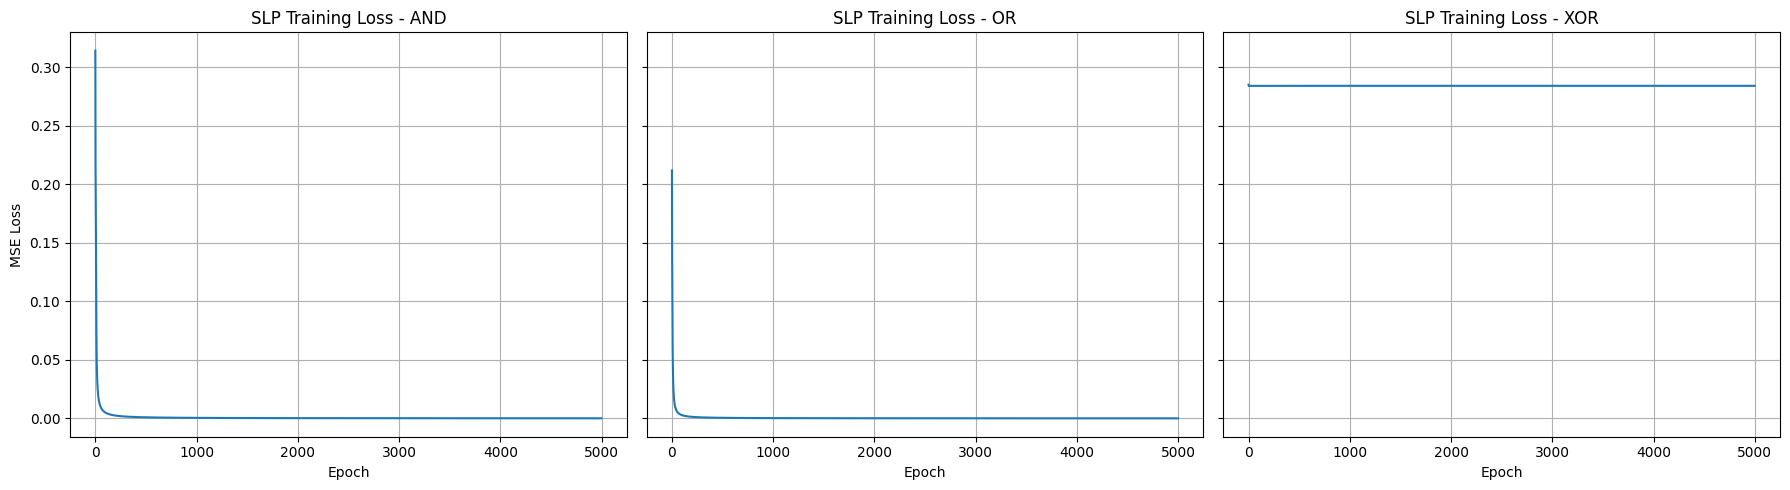

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].plot(and_loss)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("SLP Training Loss - AND")
axes[0].grid(True)

axes[1].plot(or_loss)
axes[1].set_xlabel("Epoch")
axes[1].set_title("SLP Training Loss - OR")
axes[1].grid(True)

axes[2].plot(xor_loss)
axes[2].set_xlabel("Epoch")
axes[2].set_title("SLP Training Loss - XOR")
axes[2].grid(True)

plt.tight_layout()
plt.show()